In [1]:
import os
import IPython.display as ipd
import pandas as pd
import numpy as np
import librosa
import torch
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchaudio
import lightning
import timm
import math
import scipy.signal as signal
import torchmetrics
import wandb

from typing import Dict, Any, Optional, Callable, Union
from tqdm import tqdm
from tqdm import tqdm
from torchaudio.transforms import MelSpectrogram
from torchaudio.transforms import FrequencyMasking, TimeMasking
from torchaudio.functional import amplitude_to_DB
from sklearn.model_selection import StratifiedGroupKFold
from lightning.pytorch import loggers as pl_loggers
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from time import time
from audiomentations import Compose, AddGaussianNoise, TimeStretch

%matplotlib inline

/Users/wong/esc50/base_cnn_spectrogram/.venv/lib/python3.10/site-packages/lightning/fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [12]:
DATA_ROOT = "../../esc50_data"

In [13]:
!ls -lt {DATA_ROOT} 

total 240
drwxr-xr-x  3 wong  staff     96 Jun  3 15:08 audio
-rw-r--r--  1 wong  staff   5481 Sep 21  2019 bc_utils.py
-rw-r--r--  1 wong  staff  93742 Sep 21  2019 esc50.csv
-rw-r--r--  1 wong  staff  10653 Sep 21  2019 utils.py
-rw-r--r--  1 wong  staff   8060 Sep 21  2019 utils2.py


In [ ]:
meta_df = pd.read_csv(os.path.join(DATA_ROOT,"esc50.csv"))
# meta_df.head(5)
meta_df.tail(5)

,filename,fold,target,category,esc10,src_file,take
1995,5-263831-B-6.wav,5,6,hen,False,263831,B
1996,5-263902-A-36.wav,5,36,vacuum_cleaner,False,263902,A
1997,5-51149-A-25.wav,5,25,footsteps,False,51149,A
1998,5-61635-A-8.wav,5,8,sheep,False,61635,A
1999,5-9032-A-0.wav,5,0,dog,True,9032,A


In [ ]:
# 50 categories :- 
# total examples: 400*5 = 2000 examples
# probably in each fold, each category is well represented

50

In [15]:
meta_df["fold"].value_counts()

fold
1    400
2    400
3    400
4    400
5    400
Name: count, dtype: int64

In [19]:
meta_df["target"].value_counts()

target
0     40
14    40
36    40
19    40
30    40
34    40
9     40
22    40
48    40
41    40
47    40
31    40
17    40
45    40
8     40
15    40
46    40
37    40
32    40
16    40
25    40
4     40
3     40
27    40
43    40
12    40
40    40
29    40
10    40
7     40
26    40
6     40
44    40
23    40
20    40
49    40
24    40
39    40
28    40
18    40
2     40
35    40
38    40
21    40
1     40
11    40
42    40
5     40
33    40
13    40
Name: count, dtype: int64

In [22]:
meta_df["category"].value_counts()

category
dog                 40
chirping_birds      40
vacuum_cleaner      40
thunderstorm        40
door_wood_knock     40
can_opening         40
crow                40
clapping            40
fireworks           40
chainsaw            40
airplane            40
mouse_click         40
pouring_water       40
train               40
sheep               40
water_drops         40
church_bells        40
clock_alarm         40
keyboard_typing     40
wind                40
footsteps           40
frog                40
cow                 40
brushing_teeth      40
car_horn            40
crackling_fire      40
helicopter          40
drinking_sipping    40
rain                40
insects             40
laughing            40
hen                 40
engine              40
breathing           40
crying_baby         40
hand_saw            40
coughing            40
glass_breaking      40
snoring             40
toilet_flush        40
pig                 40
washing_machine     40
clock_tick          40
sn

In [ ]:
meta_df["take"].value_counts()
# what's take? -> From the original audio file:
# say a dog barking 3 times in a 18 second file:
# we extract out the 3 (5 seconds) clips in the order A B C ...

take
A    1527
B     317
C      88
D      38
E      15
F       7
G       5
H       3
Name: count, dtype: int64

In [ ]:
meta_df["src_file"].value_counts()

# what is src_file? the original source file from which the recordings have been extracted from

src_file
51805     8
218199    8
160614    8
102414    7
198411    7
         ..
263501    1
263902    1
51149     1
61635     1
9032      1
Name: count, Length: 1524, dtype: int64

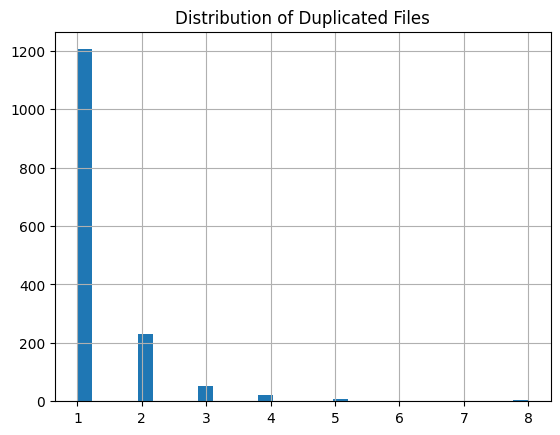

In [ ]:
plt.title("Distribution of Duplicated Files")
meta_df["src_file"].value_counts().hist(bins=30)
plt.show()

# how is duplicated files being represented here?
# from value counts we see a file is at max being used or being src referenced 8 times and minimum 1 times
# 

# Sanity Checks

In [ ]:
assert len(meta_df["filename"]) == len(set(meta_df["filename"])), "filenames are not unique"

# only unique filenames are being referenced, that is 1:1 mapping

In [ ]:
class_name2idx = meta_df[["category", "target"]].drop_duplicates("target").set_index("category")["target"].to_dict()
class_idx2name = {v:k for k,v in class_name2idx.items()} # v is target_idx, k is the category

assert (meta_df["category"].map(class_name2idx) == meta_df["target"]).all(), "class mapping is invalid"

In [ ]:
for fold_id in range(min(meta_df["fold"]), max(meta_df["fold"]) + 1):
    train_fold_df, val_fold_df = meta_df[meta_df["fold"] != fold_id], meta_df[meta_df["fold"] == fold_id]
    assert val_fold_df.shape[0] > 0, f"fold {fold_id} is empty"
    assert not set(val_fold_df["src_file"]) & set(train_fold_df["src_file"])

AssertionError: 

### Resplit
The folds are random and not correctly representative of the validation and test data distribution

In [83]:
meta_df = meta_df.drop(columns=["fold"])

In [87]:
meta_df["is_train"] = True

In [93]:
skf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
for _, val_id in skf.split(meta_df, meta_df["target"], meta_df["src_file"]):
    meta_df.iloc[val_id, -1] = False
    break

In [94]:
meta_df.head()

,filename,target,category,esc10,src_file,take,is_train
0,1-100032-A-0.wav,0,dog,True,100032,A,False
1,1-100038-A-14.wav,14,chirping_birds,False,100038,A,True
2,1-100210-A-36.wav,36,vacuum_cleaner,False,100210,A,False
3,1-100210-B-36.wav,36,vacuum_cleaner,False,100210,B,False
4,1-101296-A-19.wav,19,thunderstorm,False,101296,A,True


In [96]:
meta_df["is_train"].value_counts(normalize=True)

is_train
True     0.8995
False    0.1005
Name: proportion, dtype: float64

In [104]:
assert not set(meta_df.loc[meta_df["is_train"], "src_file"]) & set(meta_df.loc[~meta_df["is_train"], "src_file"]), "Group intersection between train and test"

In [ ]:
meta_df.loc[meta_df["is_train"]==0]

,filename,target,category,esc10,src_file,take,is_train
0,1-100032-A-0.wav,0,dog,True,100032,A,False
2,1-100210-A-36.wav,36,vacuum_cleaner,False,100210,A,False
3,1-100210-B-36.wav,36,vacuum_cleaner,False,100210,B,False
17,1-115545-A-48.wav,48,fireworks,False,115545,A,False
18,1-115545-B-48.wav,48,fireworks,False,115545,B,False
...,...,...,...,...,...,...,...
1922,5-243635-A-29.wav,29,drinking_sipping,False,243635,A,False
1942,5-250026-A-30.wav,30,door_wood_knock,False,250026,A,False
1943,5-250026-B-30.wav,30,door_wood_knock,False,250026,B,False
1945,5-250629-A-37.wav,37,clock_alarm,False,250629,A,False


In [109]:
meta_df.loc[~meta_df["is_train"], "src_file"]

0       100032
2       100210
3       100210
17      115545
18      115545
         ...  
1922    243635
1942    250026
1943    250026
1945    250629
1972    257839
Name: src_file, Length: 201, dtype: int64

In [103]:
set(meta_df.loc[~meta_df["is_train"], "src_file"])

{7973,
 11687,
 17742,
 19026,
 23094,
 24796,
 28314,
 32515,
 35687,
 36929,
 37870,
 39441,
 39937,
 43382,
 45641,
 46272,
 46938,
 52001,
 56907,
 59102,
 59321,
 60676,
 60997,
 62878,
 64962,
 67422,
 69760,
 70939,
 74517,
 79236,
 79775,
 80841,
 81190,
 82455,
 82538,
 84943,
 88409,
 94343,
 95567,
 95694,
 95695,
 97392,
 100032,
 100210,
 103415,
 104105,
 106015,
 107120,
 108017,
 108352,
 110536,
 115545,
 117293,
 117630,
 117773,
 118459,
 118817,
 118972,
 119748,
 120160,
 120586,
 122066,
 126113,
 127874,
 128160,
 129264,
 129678,
 132816,
 132852,
 142593,
 142604,
 145081,
 145382,
 150364,
 151079,
 154405,
 155130,
 155579,
 156581,
 157204,
 157615,
 159426,
 160119,
 164206,
 164688,
 167063,
 167096,
 167155,
 169127,
 171281,
 171937,
 172179,
 173568,
 177835,
 178402,
 179866,
 180256,
 181278,
 181628,
 181955,
 182041,
 182404,
 184235,
 184575,
 185415,
 185456,
 185516,
 186938,
 187504,
 188365,
 188703,
 188822,
 189832,
 191497,
 193339,
 194808,

In [102]:
set(meta_df.loc[meta_df["is_train"], "src_file"])

{155650,
 180229,
 40967,
 155659,
 155670,
 204830,
 81970,
 196660,
 196671,
 196672,
 32834,
 139331,
 188495,
 196688,
 213077,
 98392,
 172143,
 180337,
 155766,
 137,
 172180,
 82071,
 155801,
 180380,
 82077,
 188595,
 164021,
 16568,
 188606,
 147657,
 147658,
 213193,
 123086,
 254160,
 155858,
 65747,
 65748,
 65750,
 164064,
 237795,
 180453,
 188655,
 49409,
 172299,
 164120,
 205090,
 188716,
 188726,
 172366,
 221518,
 123224,
 172377,
 221528,
 221529,
 106849,
 82274,
 16746,
 98676,
 164216,
 156026,
 188796,
 221567,
 221568,
 106881,
 57733,
 164243,
 221593,
 262579,
 82367,
 57795,
 238021,
 188878,
 98771,
 172500,
 139748,
 139749,
 197103,
 262641,
 147965,
 197118,
 197121,
 188945,
 254507,
 98866,
 98869,
 156227,
 172639,
 172649,
 107117,
 107122,
 107123,
 74361,
 41615,
 66205,
 90797,
 115382,
 139958,
 221878,
 115387,
 172732,
 172733,
 172734,
 172736,
 17092,
 172742,
 25292,
 25293,
 107219,
 205526,
 107228,
 17124,
 156391,
 156393,
 164592,
 1645